# Lab Manual 3 
# Nauman Rafay
# 24i-2558
# DS-A


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%m/%d/%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%m/%d/%Y")

df.to_csv("Superstore_cleaned.csv", index=False)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task 1

Total monthly sales, plotted as a bar chart, a line chart, and a pie chart.

In [4]:
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()
monthly_sales.index = monthly_sales.index.strftime('%Y-%m')
monthly_sales.head()

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Name: Sales, dtype: float64

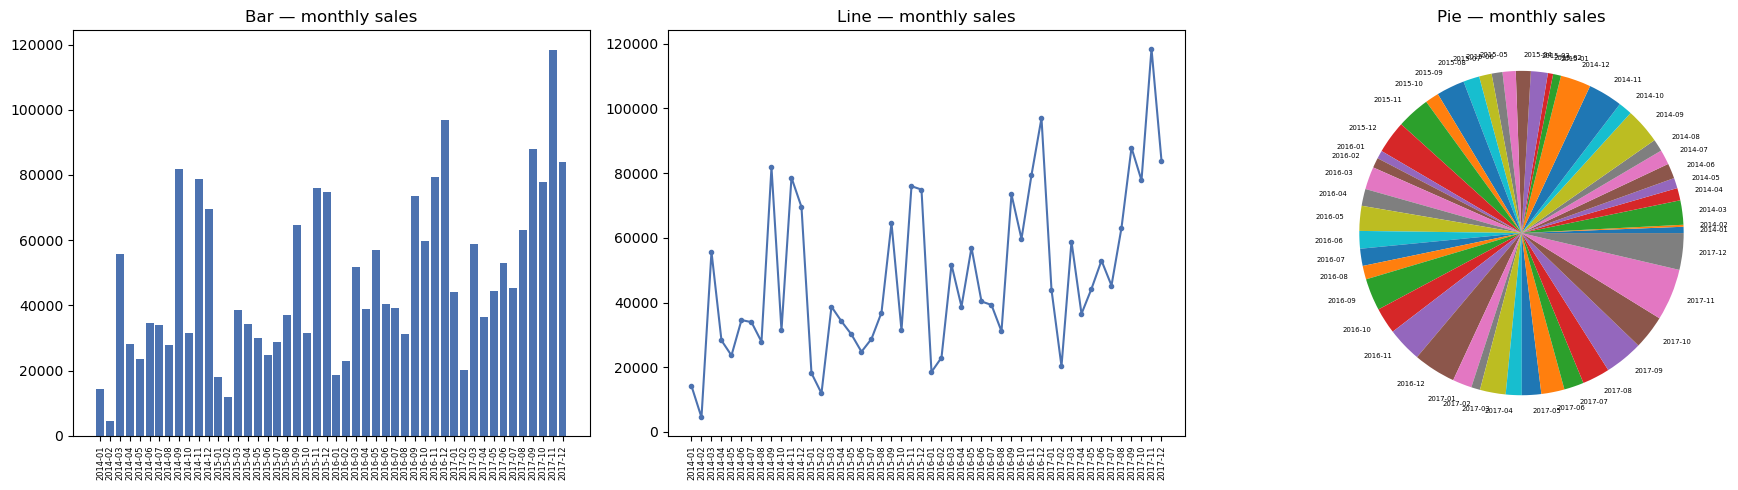

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
axes[0].bar(monthly_sales.index, monthly_sales.values, color="#4C72B0")
axes[0].set_title("Bar , monthly sales")
axes[0].tick_params(axis='x', rotation=90, labelsize=6)

# Line chart
axes[1].plot(monthly_sales.index, monthly_sales.values, marker='o', color="#4C72B0", markersize=3)
axes[1].set_title("Line , monthly sales")
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

# Pie chart 
axes[2].pie(monthly_sales.values, labels=monthly_sales.index, autopct=None, textprops={'fontsize': 5})
axes[2].set_title("Pie , monthly sales")

plt.tight_layout()
plt.show()

**Which chart shows the trend best, and which one hides it? Why?**

The line chart shows the trend best,it plots time on the x-axis in order, so the
eye can immediately follow the rise/fall pattern and see the strong seasonal spike each
November/December. 
The bar chartcarries the same information but requires more effort
to compare 48 individual bars against each other.

The pie chart hides the trend completely. Pie charts encode part-to-whole relationships,
not sequences over time, there's no time axis at all, so the 48 monthly slices are just
sorted by month and impossible to compare precisely (many are near-identical angular
slivers). It also violates the "≤4 slices" guideline from the manual by an order of magnitude.


## Task 2 


## 2a. "Compare total sales across the top 5 sub-categories." Bar chart

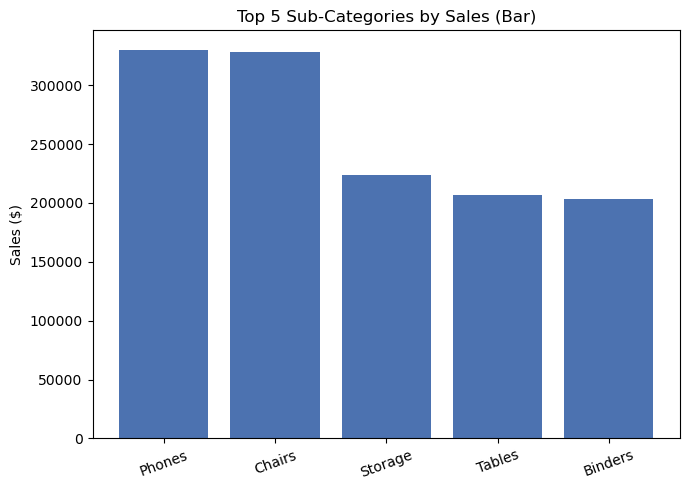

In [8]:
top5_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(top5_subcat.index, top5_subcat.values, color="#4C72B0")
ax.set_title("Top 5 Sub-Categories by Sales (Bar)")
ax.set_ylabel("Sales ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

*Justification:* A bar chart is best because the task is a direct magnitude comparison
across discrete, unordered categories bar length lets the eye rank them instantly. A pie
chart would be the weak choice: with 5 slices of fairly similar size, angular differences
are much harder to judge accurately than bar heights, so ranking sub-categories 3, 4, and 5
by eye becomes guesswork.

### 2b. "Show the revenue trend over time." 

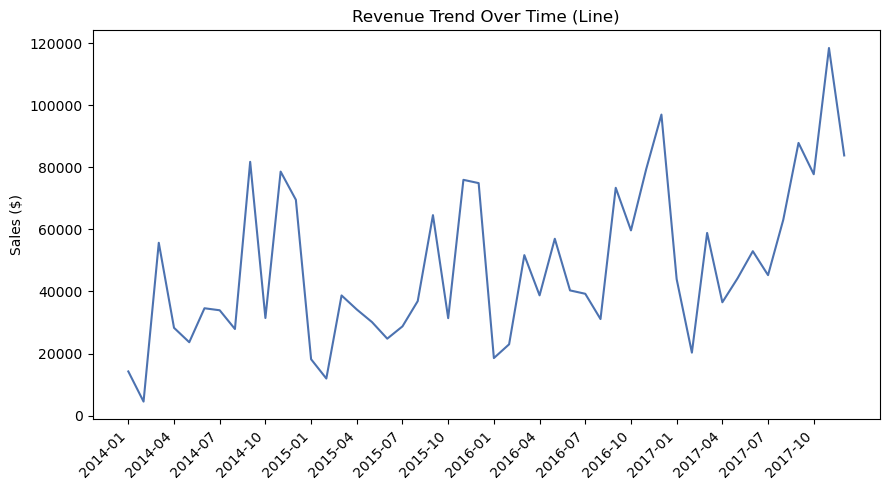

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(monthly_sales)), monthly_sales.values, color="#4C72B0")
ax.set_xticks(range(0, len(monthly_sales), 3))
ax.set_xticklabels(monthly_sales.index[::3], rotation=45, ha='right')
ax.set_title("Revenue Trend Over Time (Line)")
ax.set_ylabel("Sales ($)")
plt.tight_layout()
plt.show()

*Justification:* A line chart connects successive points, making the direction, slope,
and seasonality of the trend immediately visible. A bar chart is the weak choice here
because with 48 monthly points, the individual bars become thin and cluttered, and the
gaps between bars visually chop the sequence into disconnected units instead of a
continuous trend.

### 2c. "Show the distribution of order-line sales values."

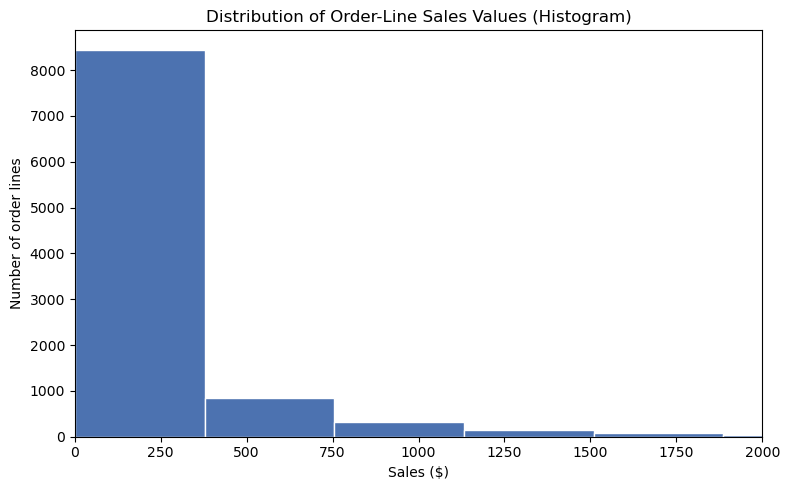

Max sale value: 22638.48  |  values shown up to $2000 for readability


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Sales'], bins=60, color="#4C72B0", edgecolor='white')
ax.set_title("Distribution of Order-Line Sales Values (Histogram)")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("Number of order lines")
ax.set_xlim(0, 2000)  # long right tail beyond this is sparse; noted below
plt.tight_layout()
plt.show()

print(f"Max sale value: {df['Sales'].max():.2f}  |  values shown up to $2000 for readability")

*Justification:* A histogram bins continuous values and shows shape, skew, and spread,
exactly what "distribution" requires. A bar chart of averages would be the weak choice:
collapsing thousands of order-lines into a single average (or a few category averages)
throws away the shape of the distribution entirely, hiding the strong right-skew and any
outliers or multi-modality.

### 2d. "Show the relationship between discount level and profit."

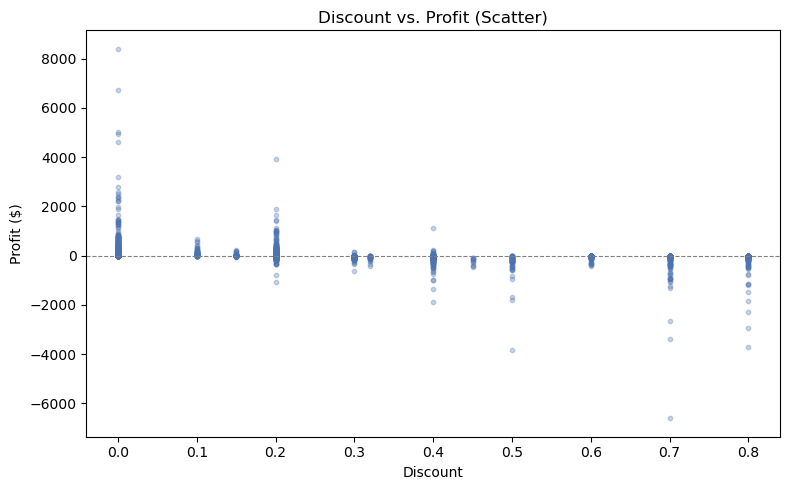

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10, color="#4C72B0")
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title("Discount vs. Profit (Scatter)")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
plt.tight_layout()
plt.show()

*Justification:* A scatter plot is the right form for correlation between two continuous
variables,each order-line is one point, so the eye can judge spread and direction of the
relationship (here, profit clearly falls, and turns negative, as discount increases). A line
chart would be the weak choice: it implies a single ordered path through the data, but
discount/profit pairs aren't sequential, so a line would either be meaningless or would
force a misleading single averaged trajectory through noisy, scattered data.

## Task 3

### 3a. Region sales

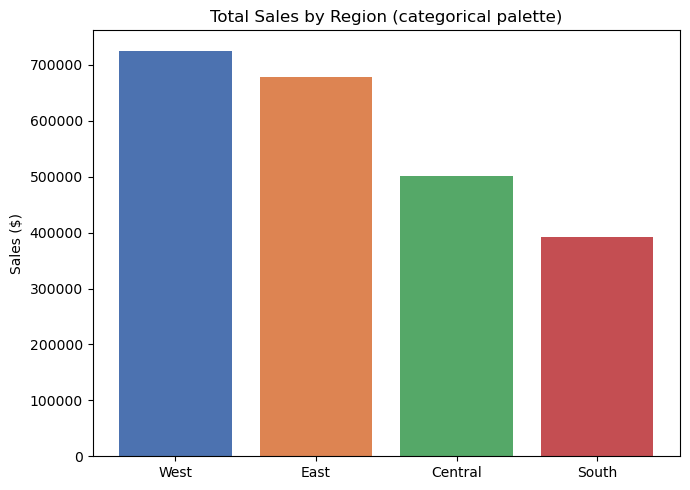

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Colorbrewer-style categorical palette, distinguishable and colorblind-safe
categorical_palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(region_sales.index, region_sales.values, color=categorical_palette[:len(region_sales)])
ax.set_title("Total Sales by Region (categorical palette)")
ax.set_ylabel("Sales ($)")
plt.tight_layout()
plt.show()

### 3b. Region × Category

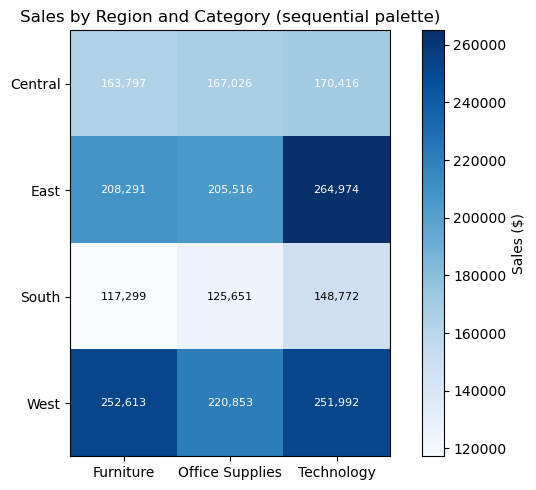

In [13]:
pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='Blues')  # single-hue, light-to-dark sequential
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Sales by Region and Category (sequential palette)")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        # dark text on light cells, light text on dark cells
        text_color = 'white' if val > pivot.values.max() * 0.6 else 'black'
        ax.text(j, i, f"{val:,.0f}", ha='center', va='center', color=text_color, fontsize=8)

fig.colorbar(im, ax=ax, label="Sales ($)")
plt.tight_layout()
plt.show()

### 3c. Monthly profit 

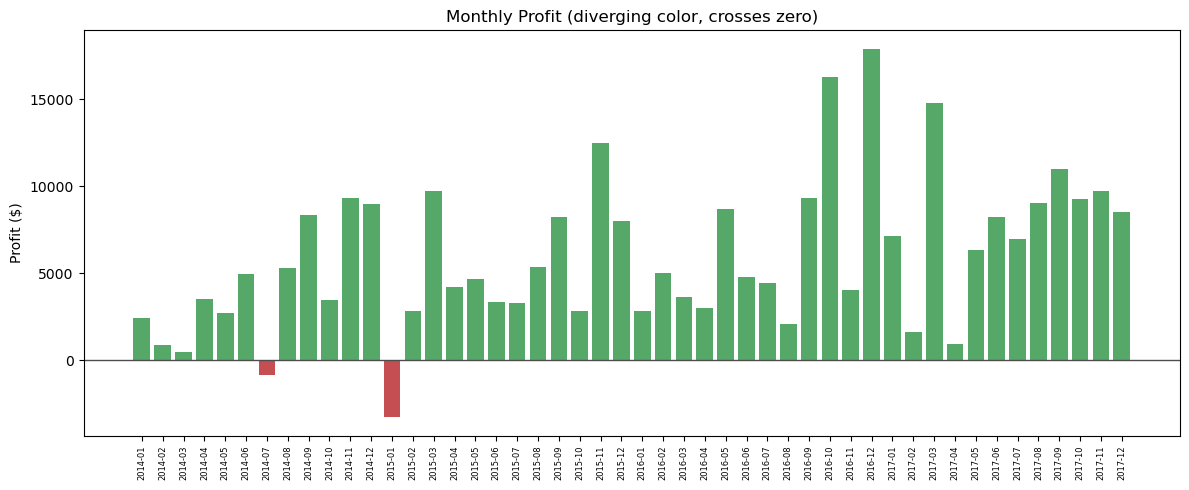

In [14]:
monthly_profit = df.set_index('Order Date').resample('MS')['Profit'].sum()
monthly_profit.index = monthly_profit.index.strftime('%Y-%m')

colors = ['#C44E52' if v < 0 else '#55A868' for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_profit.index, monthly_profit.values, color=colors)
ax.axhline(0, color='#4d4d4d', linewidth=1)
ax.set_title("Monthly Profit (diverging color, crosses zero)")
ax.set_ylabel("Profit ($)")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

## Task 4 

### 4a. WCAG contrast ratio function

In [15]:
def relative_luminance(rgb):
    """rgb: tuple of (R, G, B) in 0-255. Returns relative luminance per WCAG."""
    def channel(c):
        c = c / 255.0
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = (channel(c) for c in rgb)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(rgb1, rgb2):
    """WCAG contrast ratio between two RGB colors (0-255 tuples). Always >= 1."""
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

assert round(contrast_ratio((0,0,0), (255,255,255)), 1) == 21.0
print("contrast_ratio() OK")

contrast_ratio() OK


Test it against the colors used in Task 3 (all against a white `#FFFFFF` chart background):

In [16]:
background = hex_to_rgb('#FFFFFF')

colors_to_test = {
    'categorical: blue  #4C72B0': '#4C72B0',
    'categorical: orange #DD8452': '#DD8452',
    'categorical: green  #55A868': '#55A868',
    'categorical: red    #C44E52': '#C44E52',
    'diverging: red (loss)  #C44E52': '#C44E52',
    'diverging: green (gain) #55A868': '#55A868',
    'diverging: zero line #4d4d4d': '#4d4d4d',
}

print(f"{'Color':35s} {'Ratio':>7s}  {'AA text (4.5:1)':>17s}")
for name, hexcode in colors_to_test.items():
    ratio = contrast_ratio(hex_to_rgb(hexcode), background)
    verdict = "PASS" if ratio >= 4.5 else "FAIL"
    print(f"{name:35s} {ratio:6.2f}:1  {verdict:>17s}")

Color                                 Ratio    AA text (4.5:1)
categorical: blue  #4C72B0            4.84:1               PASS
categorical: orange #DD8452           2.80:1               FAIL
categorical: green  #55A868           2.92:1               FAIL
categorical: red    #C44E52           4.61:1               PASS
diverging: red (loss)  #C44E52        4.61:1               PASS
diverging: green (gain) #55A868       2.92:1               FAIL
diverging: zero line #4d4d4d          8.45:1               PASS


**Flagged failures:** the green (`#55A868`) and orange (`#DD8452`) fall below the 4.5:1
AA threshold for text against a white background , fine as fill color for bars, but they
should **not** be used for small text labels or thin gridlines on white; use a darker
shade or add a dark outline/label instead.

### 4b. Profit by sub-category

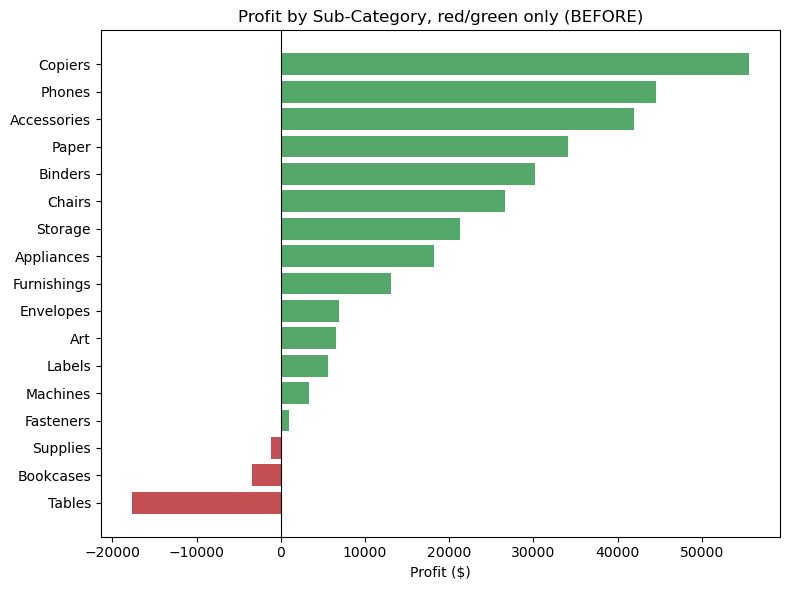

In [17]:
profit_by_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

rg_colors = [(0.77, 0.31, 0.32) if v < 0 else (0.33, 0.66, 0.41) for v in profit_by_subcat.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(profit_by_subcat.index, profit_by_subcat.values, color=rg_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Profit by Sub-Category, red/green only (BEFORE)")
ax.set_xlabel("Profit ($)")
plt.tight_layout()
plt.show()

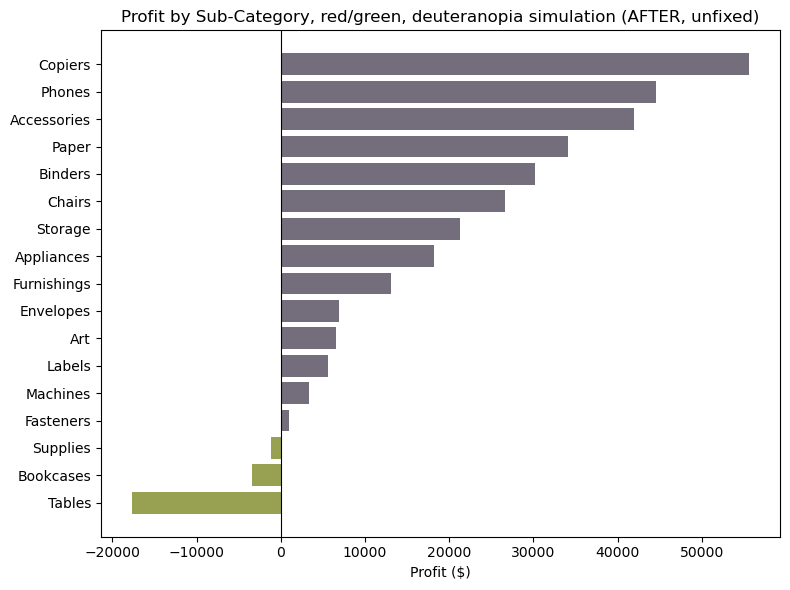

Under simulation, the 'red' loss bars and 'green' gain bars collapse toward the
same muddy yellow-brown , the loss/gain distinction is nearly lost by color alone.


In [18]:
def simulate_deuteranopia(rgb):

    r, g, b = rgb
    r2 = 0.625 * r + 0.375 * g + 0.0 * b
    g2 = 0.7 * r + 0.3 * g + 0.0 * b
    b2 = 0.0 * r + 0.3 * g + 0.7 * b
    return (r2, g2, b2)

rg_colors_simulated = [simulate_deuteranopia(c) for c in rg_colors]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(profit_by_subcat.index, profit_by_subcat.values, color=rg_colors_simulated)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Profit by Sub-Category, red/green, deuteranopia simulation (AFTER, unfixed)")
ax.set_xlabel("Profit ($)")
plt.tight_layout()
plt.show()

print("Under simulation, the 'red' loss bars and 'green' gain bars collapse toward the")
print("same muddy yellow-brown , the loss/gain distinction is nearly lost by color alone.")

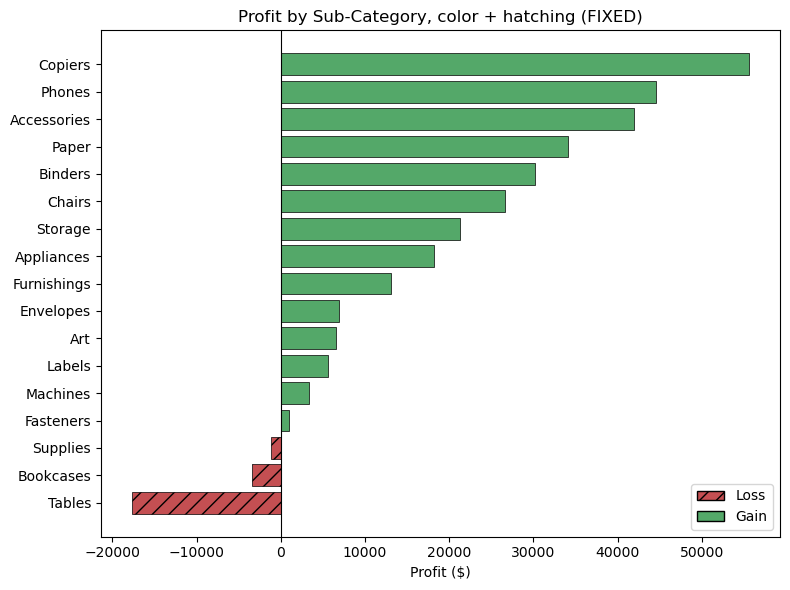

In [19]:

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, val) in enumerate(profit_by_subcat.items()):
    is_loss = val < 0
    color = (0.77, 0.31, 0.32) if is_loss else (0.33, 0.66, 0.41)
    hatch = '//' if is_loss else None
    ax.barh(name, val, color=color, hatch=hatch, edgecolor='black', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Profit by Sub-Category, color + hatching (FIXED)")
ax.set_xlabel("Profit ($)")
legend_elems = [
    Patch(facecolor=(0.77, 0.31, 0.32), hatch='//', edgecolor='black', label='Loss'),
    Patch(facecolor=(0.33, 0.66, 0.41), edgecolor='black', label='Gain'),
]
ax.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
plt.show()

**Alt text (one line):** "Horizontal bar chart of total profit by product sub-category,
ranked lowest to highest; loss bars are red with diagonal hatching and gain bars are solid
green, so the distinction between loss and gain is readable without relying on color alone."


## Task 5

### 5a. Truncated y-axis on region sales

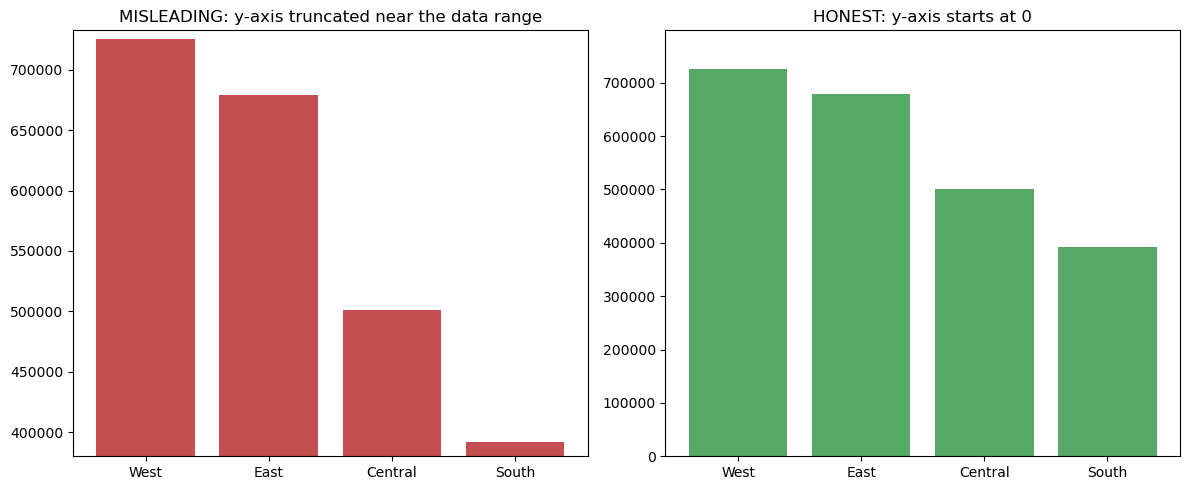

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(region_sales.index, region_sales.values, color="#C44E52")
axes[0].set_ylim(region_sales.min() * 0.97, region_sales.max() * 1.01)
axes[0].set_title("MISLEADING: y-axis truncated near the data range")

axes[1].bar(region_sales.index, region_sales.values, color="#55A868")
axes[1].set_ylim(0, region_sales.max() * 1.1)
axes[1].set_title("HONEST: y-axis starts at 0")

plt.tight_layout()
plt.show()

**Distortion:** *Truncated axis*, starting the y-axis near the minimum value visually exaggerates small percentage differences between regions into what looks like a 3-4x gap.

### 5b. Dual y-axes implying a fake correlation

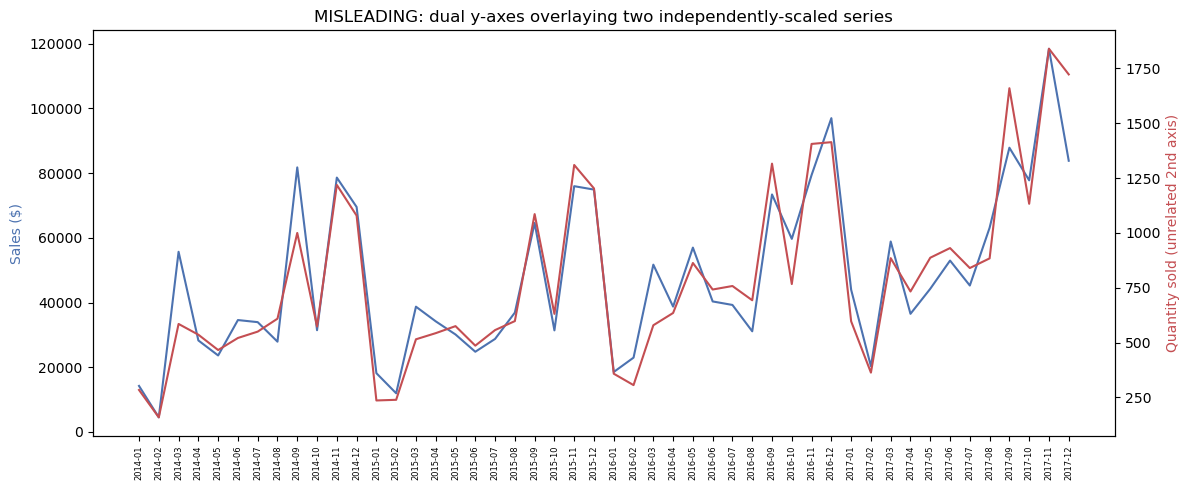

In [21]:
monthly_qty = df.set_index('Order Date').resample('MS')['Quantity'].sum()
monthly_qty.index = monthly_qty.index.strftime('%Y-%m')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_sales.index, monthly_sales.values, color="#4C72B0", label='Sales ($)')
ax1.set_ylabel("Sales ($)", color="#4C72B0")
ax1.tick_params(axis='x', rotation=90, labelsize=6)

ax2 = ax1.twinx()
ax2.plot(monthly_qty.index, monthly_qty.values, color="#C44E52", label='Postal Code (unrelated)')
ax2.set_ylabel("Quantity sold (unrelated 2nd axis)", color="#C44E52")

ax1.set_title("MISLEADING: dual y-axes overlaying two independently-scaled series")
plt.tight_layout()
plt.show()

**Distortion:** *Dual y-axes*, Sales and Quantity are each auto-scaled to their own axis, so their lines can be made to visually track each other even though the axes have no shared zero or shared scale, implying a correlation strength that the raw numbers don't support.

### 5c. Cherry-picked date window hiding the surrounding trend

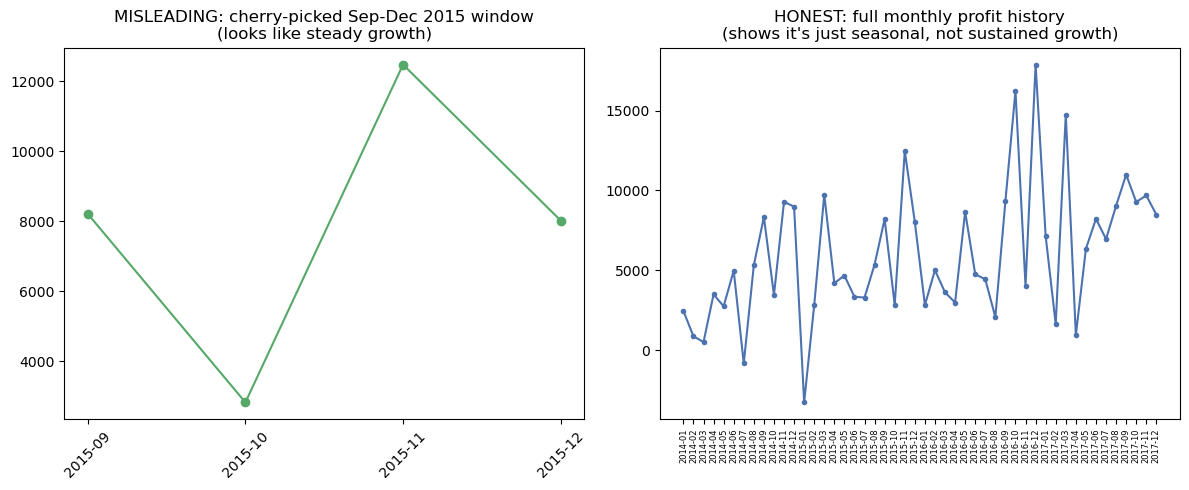

In [22]:
window = monthly_profit.loc['2015-09':'2015-12']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(window.index, window.values, marker='o', color="#55A868")
axes[0].set_title("MISLEADING: cherry-picked Sep-Dec 2015 window\n(looks like steady growth)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_profit.index, monthly_profit.values, marker='o', markersize=3, color="#4C72B0")
axes[1].set_title("HONEST: full monthly profit history\n(shows it's just seasonal, not sustained growth)")
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.show()

**Distortion:** *Cherry-picked time window*, isolating four months that happen to rise makes profit look like a sustained upward trend, while the full series shows this is just the recurring holiday-season seasonal spike.

### 5d. Bubble chart scaled by radius instead of area

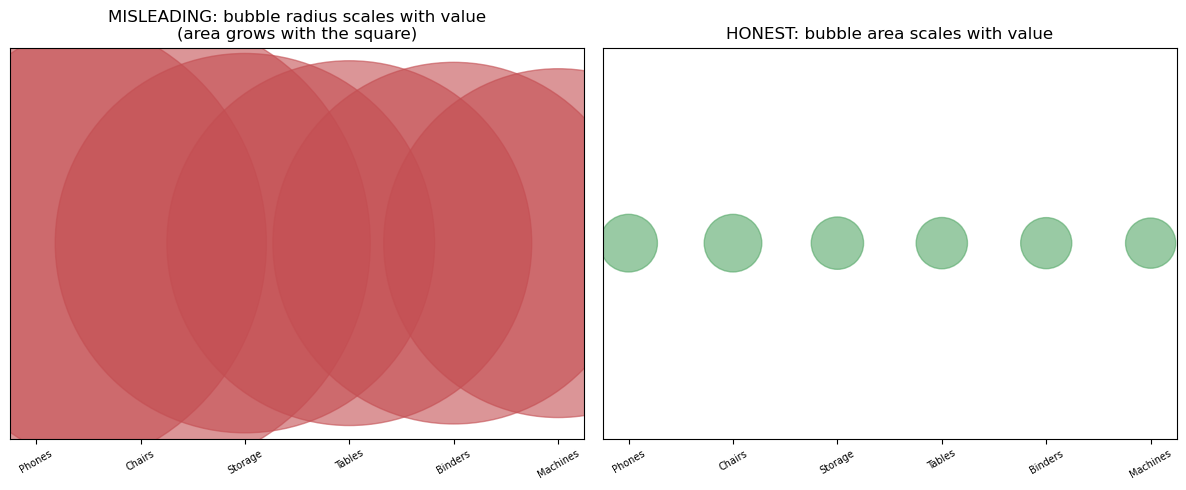

In [23]:
top10_products = df.groupby('Sub-Category').agg(Sales=('Sales','sum')).sort_values('Sales', ascending=False).head(6)
x = np.arange(len(top10_products))
values = top10_products['Sales'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Misleading: marker size (matplotlib 's') scales roughly with radius, not area
axes[0].scatter(x, [1]*len(x), s=values/3, color="#C44E52", alpha=0.6)
axes[0].set_title("MISLEADING: bubble radius scales with value\n(area grows with the square)")
axes[0].set_xticks(x); axes[0].set_xticklabels(top10_products.index, rotation=30, fontsize=7)
axes[0].set_yticks([])

# Honest: scale so that AREA is proportional to value (s is already an area-like param,
# so we take sqrt of value before feeding it in to correct for the visual distortion)
axes[1].scatter(x, [1]*len(x), s=np.sqrt(values)*3, color="#55A868", alpha=0.6)
axes[1].set_title("HONEST: bubble area scales with value")
axes[1].set_xticks(x); axes[1].set_xticklabels(top10_products.index, rotation=30, fontsize=7)
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

**Distortion:** *Radius-scaled bubbles*, a sub-category with roughly double the sales of another gets a bubble with 2x the *radius*, but since visual weight is judged by *area* (∝ radius²), it reads as having roughly 4x the sales, badly overstating the gap.

## Task 6

In [24]:
# Bin discount into levels and compute mean profit per bin , reduces overplotting
# noise from Task 2d's raw scatter while staying honest about the relationship.
bins = [-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8]
labels = ['0%', '0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
df['discount_band'] = pd.cut(df['Discount'], bins=bins, labels=labels)
avg_profit_by_band = df.groupby('discount_band', observed=True)['Profit'].mean()
avg_profit_by_band

discount_band
0%         66.900292
0-10%      96.055074
10-20%     24.738824
20-30%    -45.679636
30-40%   -109.219691
40-50%   -298.695314
50%+      -89.438144
Name: Profit, dtype: float64

### Honest chart

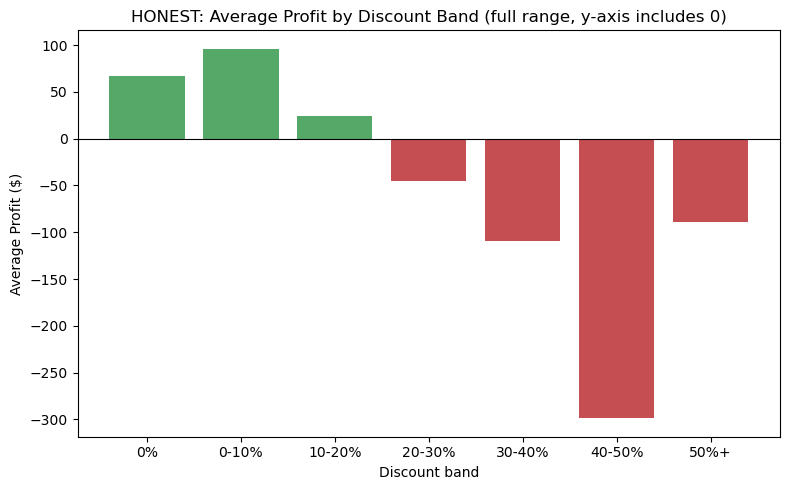

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#55A868' if v >= 0 else '#C44E52' for v in avg_profit_by_band.values]
ax.bar(avg_profit_by_band.index.astype(str), avg_profit_by_band.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("HONEST: Average Profit by Discount Band (full range, y-axis includes 0)")
ax.set_ylabel("Average Profit ($)")
ax.set_xlabel("Discount band")
plt.tight_layout()
plt.show()

### Misleading chart (same data)

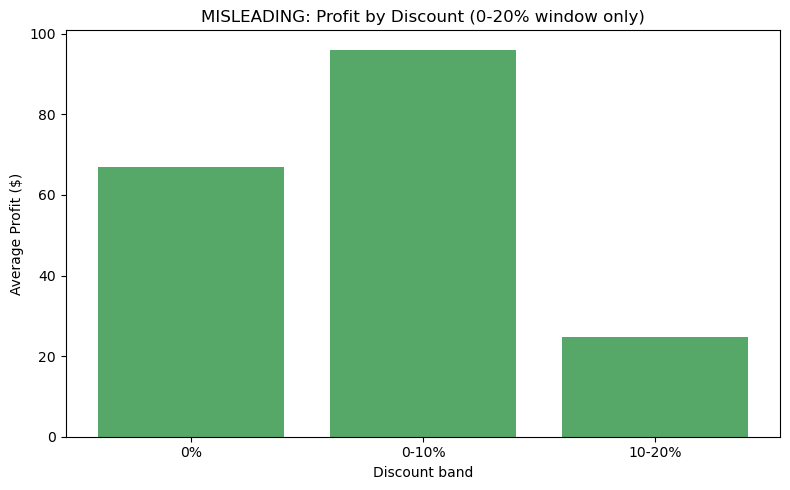

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
# Only show discount bands 0-20%, cherry-picking the range where profit still looks positive
subset = avg_profit_by_band.loc[['0%', '0-10%', '10-20%']]
ax.bar(subset.index.astype(str), subset.values, color="#55A868")
ax.set_title("MISLEADING: Profit by Discount (0-20% window only)")
ax.set_ylabel("Average Profit ($)")
ax.set_xlabel("Discount band")
plt.tight_layout()
plt.show()

**Written justification:**

*Chart type:* A bar chart of mean profit per discount band is appropriate because the
question compares a continuous driver (discount, binned into ordered groups) against an
average outcome (profit),this is a magnitude comparison across ordered categories,
which bar charts handle well. (The raw scatter from Task 2d is the right form for
showing the underlying point-level relationship; this binned bar chart is better for
directly answering "is discounting hurting profit" as a summary claim.)

*Color choice:* Red/green is used here only as a supplement to position (bars naturally
cross the zero line, so the sign is also visible from bar direction/height, not color
alone) , this keeps the chart usable under colorblindness, unlike the raw version in
Task 4b before the fix.

*Accessibility check:* Running `contrast_ratio()` from Task 4a on `#55A868` and `#C44E52`
against the white background shows both fall under the 4.5:1 AA text threshold, so no
small text is placed directly on the bar fill , only the axis labels (default dark gray
on white) carry text, which passes.

*Answer to the question:* The honest chart shows average profit is strongly positive at
0% discount, degrades through 10-20%, and turns negative from ~20% discount onward ,
discounting above roughly 20% is associated with selling at a loss on average. The
misleading version answers a different, easier question by cherry-picking only the
0-20% window, which still looks entirely profitable and hides the loss-making bands
entirely , this is the same "cherry-picked window" distortion from Task 5c, applied to
a categorical axis instead of a time axis.
